# 1. Project overview

The objective of this project is to predict monthly customer spend (`monthly_spend_pln`) based on available customer features and to compare the performance of various regression models. The problem is formulated as a regression task because the target variable `monthly_spend_pln`, is continuous.


# 2. Imports

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_validate, train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
import optuna

# 3. Load data and duplicates

The data shows an ID collision error because completely different individuals were mistakenly assigned the exact same `customer_id`. This is clear because a single ID displays impossible changes over time, such as a customer's age dropping significantly between registration dates. 

There are 60 duplicated rows with 30 duplicated clients. The records with duplicated `customer_id` contain different demographic data. Therefore, it can be assumed that these are genuine time series representing a natural lifecycle, where changes in the database indicate, for example, a relocation or a package upgrade. 

In [5]:
data = pd.read_csv("../data/subscription_customers_dirty.csv")

data.head()

,customer_id,age,city,plan,acquisition_channel,join_date,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
0,C000001,32,Poznań,Basic,referral,2022-05-21,7500.94,37,15,1,9.0,1,5,149.74,0
1,C000002,38,Łódź,Standard,paid_search,2024-11-26,5549.57,7,0,0,6.0,1,0,94.50,0
2,C000003,39,Warszawa,Basic,referral,2023-05-25,13992.16,25,9,3,6.0,1,0,127.67,0
3,C000004,39,Warszawa,Standard,organic,2022-09-29,8370.21,33,8,0,7.0,1,15,175.89,0
4,C000005,38,Gdańsk,Premium,referral,2025-06-07,9492.17,1,14,0,7.0,1,0,167.46,1


In [7]:
dup_cols = ['customer_id', 'age', 'city', 'plan', 'acquisition_channel', 'join_date']
duplicates = data[data.duplicated(subset=['customer_id'], 
                                  keep=False)].sort_values(by='customer_id')[dup_cols]

print(duplicates)

     customer_id  age      city      plan acquisition_channel   join_date
60       C000061   48   Wrocław  Standard         paid_search  2022-03-05
7447     C000061   26    Kraków   Premium             organic  2025-03-07
5727     C000494   39  Katowice  Standard             organic  2024-01-06
493      C000494   24    Lublin  Standard         paid_search  2024-10-31
884      C000885   41    Lublin     Basic             partner  2024-07-06
3095     C000885   34   Wrocław   Premium         paid_search  2024-10-21
5061     C001389   46  Katowice     Basic         paid_search  2025-06-06
1388     C001389   54    Poznań   Premium            referral  2022-07-17
1528     C001529   42   Wrocław  Standard             organic  2023-07-20
7651     C001529   19      Łódź  Standard             organic  2025-03-18
1942     C001943   31   Wrocław  Standard         paid_search  2022-09-14
1310     C001943   31    Gdańsk  Standard         paid_search  2024-05-12
8056     C002540   36    Gdańsk    Bas

# 4. Data quality & cleaning 

Instead of removing entire rows with data errors, they were replaced with `NaN` values.

* `age`: Replaced values $< 18$ or $\ge 99$ with `NaN` to handle outliers and out-of-scope entries.
* `monthly_spend_pln`: Replaced negative values with `NaN`. Rows with missing values in this target variable were dropped, followed by an index reset.
* `monthly_income_pln`: Replaced negative values and known sentinel missing code values (`999999`) with `NaN`.

In [7]:
data.drop(columns=['customer_id', 'join_date'], inplace=True)

categorical_cols = ['city', 'plan', 'acquisition_channel']
for col in categorical_cols:
    data[col] = data[col].str.strip().str.lower()

data.loc[
    (data['age'] >= 99) |
    (data['age'] < 18),
    'age'
] = np.nan

data.loc[
    (data['monthly_spend_pln'] < 0),
    'monthly_spend_pln'
] = np.nan

data.loc[
    (data['monthly_income_pln'] < 0) |
    (data['monthly_income_pln'] == 999999),
    'monthly_income_pln'
] = np.nan

data['monthly_spend_pln'].isna().sum()
data = data.dropna(subset=["monthly_spend_pln"]).reset_index(drop=True)

print("Missing values after cleaning:")
display(data.isna().sum().sort_values(ascending=False))

Missing values after cleaning:


monthly_income_pln          157
satisfaction_score          130
city                        109
age                           8
plan                          0
acquisition_channel           0
tenure_months                 0
avg_logins_last_30d           0
support_tickets_last_30d      0
auto_renew                    0
discount_pct                  0
monthly_spend_pln             0
churned                       0
dtype: int64

# 5. Exploratory data analysis

* `data.info()` shows a general overview of the dataset. The dataset contains $9,967$ rows and $13$ columns. It includes both numerical and categorical variables. Some columns contain missing values. The missing values appear in `age`, `city`, `monthly_income_pln`, and `satisfaction_score`. The other columns have complete data.

* `data.describe()` presents average customer is about $35$ years old and has been with the company for around $21$ months. The average monthly income is approximately $8,653 PLN$, while the average monthly spend is about $140$ PLN. Most customers log in around $11$ times during the last 30 days. The average satisfaction score is about $7.8$ out of $10$. Most customers also have autom-renew enabled.
The `monthly_spend_pln` variable has a large range, from $0$ to $2,500 PLN$. This may suggest the presence of some unusually high values, that can be outl.

* Based on the heat map, `tenure_months` and `avg_logins_last_30d` appear to have the strongest relationship with `monthly_spend_pln`.


In [8]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       9989 non-null   float64
 1   city                      9888 non-null   object 
 2   plan                      9997 non-null   object 
 3   acquisition_channel       9997 non-null   object 
 4   monthly_income_pln        9840 non-null   float64
 5   tenure_months             9997 non-null   int64  
 6   avg_logins_last_30d       9997 non-null   int64  
 7   support_tickets_last_30d  9997 non-null   int64  
 8   satisfaction_score        9867 non-null   float64
 9   auto_renew                9997 non-null   int64  
 10  discount_pct              9997 non-null   int64  
 11  monthly_spend_pln         9997 non-null   float64
 12  churned                   9997 non-null   int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 1015.4+ KB


,age,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
count,9989.000000,9840.000000,9997.000000,9997.000000,9997.000000,9867.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,35.217139,8663.042901,20.793138,10.688306,0.666500,7.807135,0.768731,7.192158,139.985437,0.192658
std,9.652617,3985.200991,12.237488,4.431403,1.055299,1.271001,0.421665,7.459601,66.396193,0.394406
min,18.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,5832.465000,10.000000,8.000000,0.000000,7.000000,1.000000,0.000000,109.510000,0.000000
50%,35.000000,7824.505000,21.000000,11.000000,0.000000,8.000000,1.000000,5.000000,138.490000,0.000000
75%,42.000000,10599.945000,31.000000,14.000000,1.000000,9.000000,1.000000,15.000000,166.170000,0.000000
max,71.000000,35000.000000,42.000000,29.000000,12.000000,10.000000,1.000000,20.000000,2500.000000,1.000000


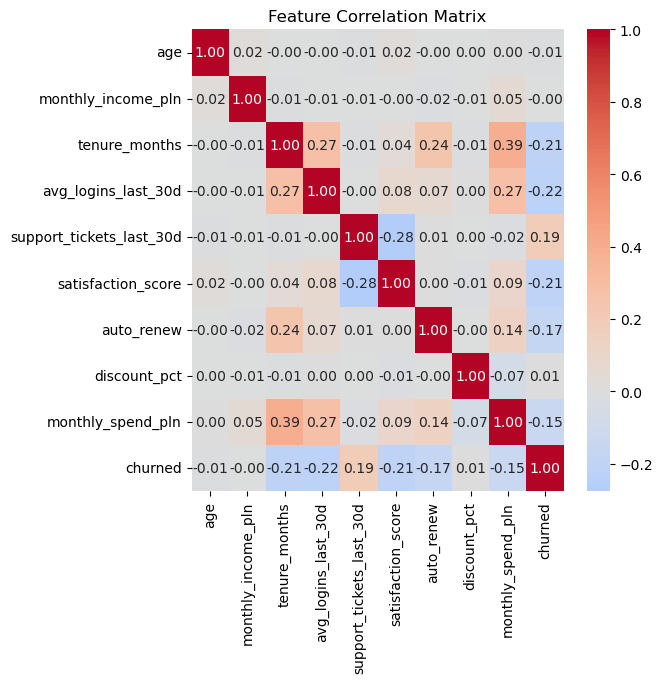

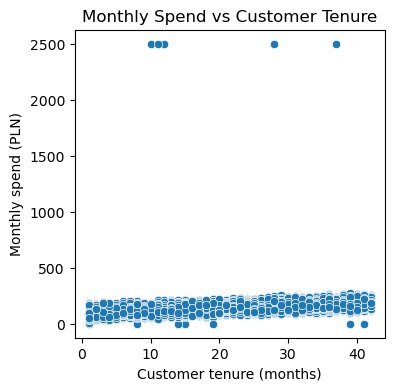

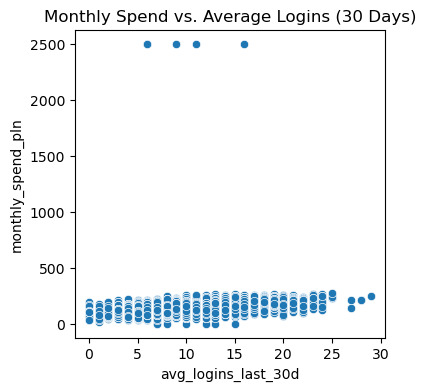

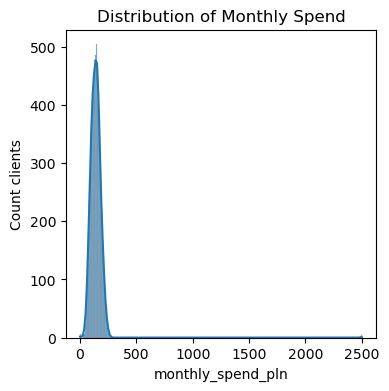

In [9]:
plt.figure(figsize=(6, 6))
sns.heatmap(data.select_dtypes("number").corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f") 
plt.title('Feature Correlation Matrix')
plt.show()

plt.figure(figsize=(4, 4))
sns.scatterplot(data, x="tenure_months", y="monthly_spend_pln")
plt.title('Monthly Spend vs Customer Tenure')
plt.xlabel("Customer tenure (months)")
plt.ylabel("Monthly spend (PLN)")
plt.show()

plt.figure(figsize=(4, 4))
sns.scatterplot(data, x="avg_logins_last_30d", y="monthly_spend_pln")
plt.title('Monthly Spend vs. Average Logins (30 Days)')
plt.show()

plt.figure(figsize=(4, 4))
sns.histplot(data["monthly_spend_pln"], kde=True)
plt.ylabel('Count clients')
plt.title('Distribution of Monthly Spend')
plt.show()

# 6. Feature engineering and target definition

In this step, the features are separated from the target variable. The target variable is `monthly_spend_pln` so it is removed from input features. Churned was also excluded because it represents an outcome that may occur after or be directly related to the prediction period. Including it could introduce target leakage depending on when the feature is observed

The new feature `icnome_per_tenure` combines income and customer tenure into one variable. It may help the model find a relationship between a customer's income and how long they have been a customer.

The `high_spend` variable contains `monthly_spend_pln values` ​​with values ​​above 500. There are 5 such records that have the same value of 2500. They could be treated as erroneous data however such values ​​are theoretically possible, and the remaining feature columns do not contain errors in the data.

In [10]:
X = data.drop(columns=[
    "monthly_spend_pln",
    "churned"
])
y = data["monthly_spend_pln"]

X["income_per_tenure"] = (
    X["monthly_income_pln"] / (X["tenure_months"] + 1)
)

X["income_per_tenure"]

high_spend = data["monthly_spend_pln"] >= 500
data[high_spend]

,age,city,plan,acquisition_channel,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
2388,47.0,wrocław,standard,social,10716.70,10,6,1,9.0,0,10,2500.0,0
2933,36.0,lublin,basic,organic,2840.60,12,16,0,6.0,0,20,2500.0,1
3272,42.0,łódź,basic,paid_search,14278.43,37,11,2,7.0,1,10,2500.0,0
3371,19.0,lublin,standard,paid_search,10223.06,28,6,0,8.0,1,0,2500.0,0
9698,33.0,kraków,standard,organic,7617.57,11,9,1,NaN,0,20,2500.0,0


# 7. Train/test split

Standard split is used ($80/20$). The model learns from the training data, while the test data is used later to check how well the final model works on unseen data. Set `random_state=42` to make the split reproducible.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 8. Preprocessing pipeline

For numerical features, missing values are replaced with the median and the values are standardized.
For categorical features, missing values are replaced with the most frequent value. Then, categorical variables are converted into numerical values using one-hot encoding.

All preprocessing steps are placed inside a scikit-learn pipeline. This makes sure that the preprocessing is fitted only on the training data and to avoid data leackage.

In [12]:
reg_numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', StandardScaler())])
reg_categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
numeric_selector = make_column_selector(dtype_include="number")
categorical_selector = make_column_selector(dtype_include="object")

preprocessor = ColumnTransformer([('num', reg_numeric_transformer, numeric_selector),
                                 ('cat', reg_categorical_transformer, categorical_selector)])

In [13]:
pipelines = { 
    "Linear Regression": Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())]), 
    "Ridge": Pipeline([('preprocessor', preprocessor), ('regressor', Ridge(alpha=1.0))]), 
    "Lasso": Pipeline([('preprocessor', preprocessor), ('regressor', Lasso(alpha=1.0))]), 
    "Elastic Net": Pipeline([('preprocessor', preprocessor), ('regressor', ElasticNet(alpha=1.0))]), 
    "Decision Tree": Pipeline([('preprocessor', preprocessor), ('regressor', DecisionTreeRegressor(random_state=42))]),
    "XGB": Pipeline([('preprocessor', preprocessor), ('regressor', XGBRegressor(random_state=42))])
}

# 9. Cross validation

5-fold cross-validation used to compare the regression models more reliably. The training data is divided into five parts. The model is trained on four parts and tested on the remaining part. This process is repeated five times.

Three metrics: MAE, RMSE, and R² are used. Ridge and Linear Regression give the best baseline results. Lasso also performs well, while Decision Tree gives the weakest results.


In [14]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "r2": "r2"
}

cv_results = []
saved_feature_importances = {}

for name, model in pipelines.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    fold_rmse = np.sqrt(-scores["test_mse"])

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_mae"].mean(),
        "CV RMSE": fold_rmse.mean(),
        "CV RMSE std": fold_rmse.std(),
        "CV R2": scores["test_r2"].mean()
    })

comparison_cv = (
    pd.DataFrame(cv_results)
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

comparison_cv

,Model,CV MAE,CV RMSE,CV RMSE std,CV R2
0,Linear Regression,13.233529,56.839836,23.167689,0.358860
1,Ridge,13.234600,56.840507,23.167516,0.358845
2,Lasso,13.847640,57.014165,22.945032,0.355390
3,Elastic Net,20.247469,60.221822,20.773405,0.278263
4,XGB,16.788792,64.853898,15.928276,0.122123
5,Decision Tree,21.113046,95.993693,19.056887,-1.270959


# 10. Hyperparameter optimalization for Lasso and Ridge

Optimalization of two best models (Ridge and Lasso) using Grid Search. The best value for Ridge is `alpha = 1`. The best value for Lasso is `alpha = 0.2`.

Lasso gives a slightly better cross-validation RMSE than Ridge, so I select Lasso as the strongest linear model, but difference is pretty small.


In [15]:
# 11. Hyperparameter Optimalization - Grid Search

ridge_grid = GridSearchCV(
    estimator=pipelines["Ridge"],
    param_grid={
        "regressor__alpha": [
            0.00001, 
            0.0001,
            0.001,
            0.01, 
            0.1, 
            1, 
]
    },
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Ridge best params:")
print(ridge_grid.best_params_)
print(-ridge_grid.best_score_)


lasso_grid = GridSearchCV(
    estimator=pipelines["Lasso"],
    param_grid={
        "regressor__alpha": [
            0.05,
            0.075,
            0.1,
            0.125,
            0.15,
            0.2,
            0.3
        ]
    },
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Lasso best params:")
print(lasso_grid.best_params_)
print(-lasso_grid.best_score_)

Ridge best params:
{'regressor__alpha': 1}
56.84050732935193
Lasso best params:
{'regressor__alpha': 0.2}
56.80970281943441


# 11. XGBoost hyperparameter optimalization with Optuna

Optuna was used to find better hyperparameters for the XGBoost model. XGB ranked second to last in the test, but hyperparameter tuning might improve the score. After ten trials, the best XGBoost configuration achieves a cross-validation RMSE of about $57.36$. This is better than the original XGBoost model, but it is still worse than the best Lasso and Ridge models. Therefore, XGBoost is not selected as the final model.


In [16]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'random_state': 42
    }
    
    xgb_optuna = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(**params))
    ])
    
    scores = cross_val_score(
        xgb_optuna,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=75)

best_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        **study.best_params,
        random_state=42
    ))
])

print('Best Optuna parameters:')
for key, value in study.best_params.items():
    print(f"{key}: {value}")
print(f'Best CV RMSE: {study.best_value:.2f}')


[I 2026-09-02 11:32:55,638] A new study created in memory with name: no-name-541e500f-512c-4bbd-a064-0455a9f327e3
[I 2026-09-02 11:32:56,294] Trial 0 finished with value: 64.81890130886092 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.18583502357561257, 'subsample': 0.7338827225411604, 'colsample_bytree': 0.5108556555815071, 'gamma': 2.214944000880434e-07}. Best is trial 0 with value: 64.81890130886092.
[I 2026-09-02 11:32:57,111] Trial 1 finished with value: 60.25385737098496 and parameters: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.017452940464055232, 'subsample': 0.6991844626011806, 'colsample_bytree': 0.8883603489367982, 'gamma': 0.002648697547708645}. Best is trial 1 with value: 60.25385737098496.
[I 2026-09-02 11:32:57,989] Trial 2 finished with value: 63.22875797494828 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.0516456738141971, 'subsample': 0.6566980358076018, 'colsample_bytree': 0.7673684893667146, 'gamma'

Best Optuna parameters:
n_estimators: 300
max_depth: 2
learning_rate: 0.03171819719026629
subsample: 0.9942206682696462
colsample_bytree: 0.5000345460451483
gamma: 0.00031666486549690855
Best CV RMSE: 57.33


# 12. Final model evaluation

Now best tuned versions of Ridge, Lasso and XGBoost are compared with the rest of basic models. Based on cross-validation, Lasso performs best. It has a CV MAE of about 13.24 PLN, a CV RMSE of about 56.81 PLN, and an R² of about 0.36. The best Lasso model is evaluated on the test set.
The test results are:

* MAE: 11.44 PLN
* RMSE: 14.57 PLN
* R²: 0.87

The test results are much better than the cross-validation results. However, this difference needs to be interpreted carefully because the target variable has a very skewed distribution (Module 6). 

There are only five observations with monthly spending of at least 500 PLN. All five observations are in the training set, while there are no such observations in the test set.This is important because the test set contains only lower spending values. As a result, the test set is easier for the model than some of the cases in the training data.

**This helps explain why the test RMSE and R² are much better than the cross-validation results.**


In [17]:
best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_

finalists = {
    "Ridge GridSearch": best_ridge,
    "Lasso GridSearch": best_lasso,
    "XGB Optuna": best_xgb
}

final_results = []

for name, model in finalists.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )

    final_results.append({
        "Model": name,
        "CV MAE": -scores["test_mae"].mean(),
        "CV RMSE": -scores["test_rmse"].mean(),
        "CV RMSE std": scores["test_rmse"].std(),
        "CV R2": scores["test_r2"].mean()
    })

comparison_all = (
    pd.DataFrame(cv_results + final_results)
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

comparison_all

,Model,CV MAE,CV RMSE,CV RMSE std,CV R2
0,Lasso GridSearch,13.244780,56.809703,23.177856,0.359523
1,Linear Regression,13.233529,56.839836,23.167689,0.358860
2,Ridge,13.234600,56.840507,23.167516,0.358845
3,Ridge GridSearch,13.234600,56.840507,23.167516,0.358845
4,Lasso,13.847640,57.014165,22.945032,0.355390
5,XGB Optuna,14.252799,57.332746,22.760067,0.348700
6,Elastic Net,20.247469,60.221822,20.773405,0.278263
7,XGB,16.788792,64.853898,15.928276,0.122123
8,Decision Tree,21.113046,95.993693,19.056887,-1.270959


In [18]:
y_pred_lasso = best_lasso.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_lasso)
final_rmse = root_mean_squared_error(y_test, y_pred_lasso)
final_r2 = r2_score(y_test, y_pred_lasso)

print(f"Final MAE:  {final_mae:.4f}")
print(f"Final RMSE: {final_rmse:.4f}")
print(f"Final R²:   {final_r2:.4f}")

Final MAE:  11.4453
Final RMSE: 14.5722
Final R²:   0.8739


In [19]:
# These five records represent churn analysis data for users across various Polish cities who share an identical, high monthly expense of 2,500 PLN. 

print(">500 spend - train:", (y_train >= 2500).sum())
print(">500 spend - test:", (y_test >= 2500).sum())

>500 spend - train: 5
>500 spend - test: 0


# 13. Final model diagnostics

The Actual vs Predicted plot compares the real monthly spending values with the model predictions. Points closer to the diagonal line represent more accurate predictions.

The Residual Plot shows the prediction errors across the range of predicted values. It helps identify systematic errors and unusual observations.

The plots suggest that the model performs better for typical spending values, while some larger errors appear at the lower and higher ends of the target range.


In [20]:
final_comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "CV": [
        comparison_all.loc[
            comparison_all["Model"] == "Lasso GridSearch", "CV MAE"
        ].iloc[0],
        comparison_all.loc[
            comparison_all["Model"] == "Lasso GridSearch", "CV RMSE"
        ].iloc[0],
        comparison_all.loc[
            comparison_all["Model"] == "Lasso GridSearch", "CV R2"
        ].iloc[0]
    ],
    "Test": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

final_comparison

,Metric,CV,Test
0,MAE,13.244780,11.445344
1,RMSE,56.809703,14.572250
2,R²,0.359523,0.873944


In [21]:
diagnostics = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred_lasso
})

diagnostics["residual"] = diagnostics["y_true"] - diagnostics["y_pred"] 

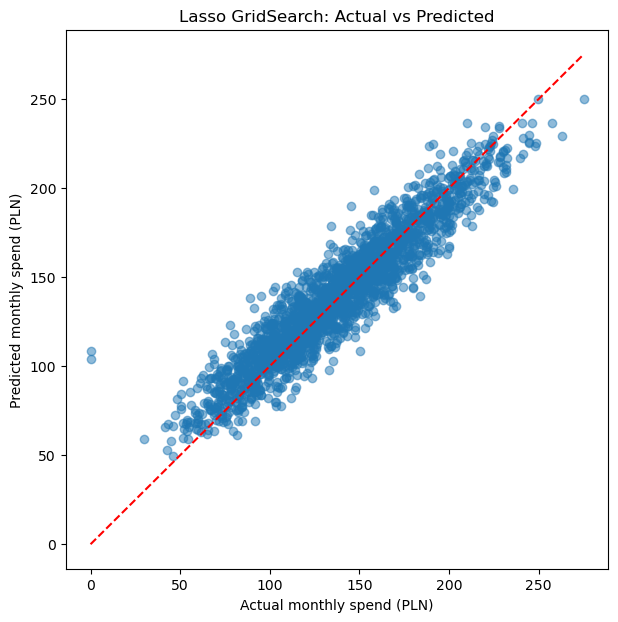

In [22]:
plt.figure(figsize=(7, 7))

plt.scatter(
    diagnostics["y_true"],
    diagnostics["y_pred"],
    alpha=0.5
)

max_value = max(
    diagnostics["y_true"].max(),
    diagnostics["y_pred"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    color='red'
)

plt.xlabel("Actual monthly spend (PLN)")
plt.ylabel("Predicted monthly spend (PLN)")
plt.title("Lasso GridSearch: Actual vs Predicted")

plt.show()

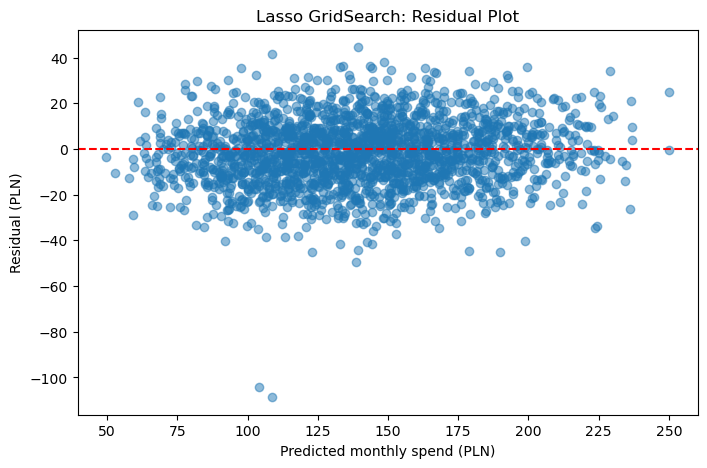

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(
    diagnostics["y_pred"],
    diagnostics["residual"],  
    alpha=0.5
)

plt.axhline(0, linestyle="--", color='red')

plt.xlabel("Predicted monthly spend (PLN)")
plt.ylabel("Residual (PLN)")
plt.title("Lasso GridSearch: Residual Plot")

plt.show()


# 14. Error analysis by spending group

For each observation, there is calculated `prediction error` and the `absolute error`. Then results are sorted by absolute error to find the cases where the model made the largest mistakes.

  
To better understand the model's errors test observations are divided into several spending groups. The model performs best for customers with actual spending between 150 and 200 PLN, with an MAE of about 10.52 PLN. For customers spending 100 PLN or less, the MAE increases to about 15.40 PLN. The negative mean error also shows that the model tends to overestimate spending in this group. For higher-spending customers, the model tends to underestimate the actual spending. This can be seen from the positive mean error for the 150–200 PLN and 200–300 PLN groups.


In [24]:
diagnostics["absolute_error"] = (
    diagnostics["residual"].abs()
)

diagnostics.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,y_true,y_pred,residual,absolute_error
534,0.00,108.664530,-108.664530,108.664530
893,0.00,104.223566,-104.223566,104.223566
1242,88.87,138.433475,-49.563475,49.563475
127,77.79,123.061369,-45.271369,45.271369
1452,145.05,189.975292,-44.925292,44.925292
27,183.99,139.455323,44.534677,44.534677
74,134.39,178.888963,-44.498963,44.498963
784,95.13,139.371662,-44.241662,44.241662
1263,150.47,108.690473,41.779527,41.779527
1896,91.00,132.763392,-41.763392,41.763392


In [25]:
diagnostics["spend_group"] = pd.cut(
    diagnostics["y_true"],
    bins=[-np.inf, 100, 150, 200, 300, np.inf],
    labels=[
        "≤100",
        "100–150",
        "150–200",
        "200–300",
        ">300"
    ]
)

diagnostics.groupby(
    "spend_group",
    observed=True
).agg(
    n=("y_true", "size"),
    MAE=("absolute_error", "mean"),
    Mean_Error=("residual", "mean")
)

,n,MAE,Mean_Error
spend_group,,,
≤100,378,13.479274,-11.206649
100–150,835,10.836353,-2.974506
150–200,637,10.870451,3.234800
200–300,150,12.151274,9.250965


# 15. Highest target values

The observations with the highest actual monthly spending are examined. The actual values range from 244.88 PLN to 265.13 PLN. Most of these values are underestimated by the model.

The largest underestimation is observed for the customer with actual spending of 248.55 PLN, where the predicted value is 210.31 PLN. The smallest error is observed for the customer with actual spending of 249.70 PLN, where the predicted value is 250.24 PLN.

Overall, the model performs reasonably well for most high-spending observations, but some of the highest values are underestimated.

In [26]:
diagnostics.sort_values(
    "y_true",
    ascending=False
).head(10)

,y_true,y_pred,residual,absolute_error,spend_group
1665,275.15,250.181647,24.968353,24.968353,200–300
820,263.13,229.024193,34.105807,34.105807,200–300
762,257.48,236.465554,21.014446,21.014446,200–300
153,249.70,249.974172,-0.274172,0.274172,200–300
1341,248.52,225.367264,23.152736,23.152736,200–300
1691,248.13,223.389516,24.740484,24.740484,200–300
304,246.22,236.807791,9.412209,9.412209,200–300
1989,244.88,225.175822,19.704178,19.704178,200–300
1002,244.45,226.004718,18.445282,18.445282,200–300
1965,244.43,230.028341,14.401659,14.401659,200–300


# 16. Lasso feature coefficients 

The coefficients of the final Lasso model are examined to understand which features have the strongest relationship with predicted monthly spending.
The absolute value of each coefficient is used to identify the features with the largest impact on the model predictions.
A positive coefficient is associated with higher predicted spending, while a negative coefficient is associated with lower predicted spending.

The largest coefficients are related to the premium and basic plans, as well as `tenure_months`. The premium plan, longer tenure, and more logins are associated with higher predicted monthly spending, while the basic plan and higher discounts are associated with lower predicted spending. Some features, such as age and several acquisition channels, have zero or very small coefficients and therefore have little impact on the model.


In [27]:
feature_names = best_lasso.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": best_lasso.named_steps[
        "regressor"
    ].coef_
})

coefficients["abs_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients.sort_values(
    "abs_coefficient",
    ascending=False
).head(20)

,feature,coefficient,abs_coefficient
18,cat__plan_premium,33.369942,33.369942
17,cat__plan_basic,-27.977744,27.977744
2,num__tenure_months,23.505504,23.505504
3,num__avg_logins_last_30d,6.038769,6.038769
7,num__discount_pct,-4.196567,4.196567
14,cat__city_warszawa,3.980198,3.980198
1,num__monthly_income_pln,3.781298,3.781298
5,num__satisfaction_score,3.706769,3.706769
11,cat__city_kraków,1.694925,1.694925
15,cat__city_wrocław,1.530015,1.530015


# 17. Repeated cross-validation

Repeated cross-validation is used to check the stability of the final Lasso model.

The data is split into 10 folds, and the process is repeated 10 times with different splits. This gives a more reliable estimate of the model's performance.

The average results are:

* MAE: 13.22 PLN
* RMSE: 46.51 PLN
* RMSE standard deviation: 40 PLN
* R²: 0.57

Repeated cross-validation gave us a more reliable measure of how well the model performs. The model achieved a relatively low average absolute error, but RMSE was much higher. This suggests that the model performed reasonably well for most observations but made large errors for a small number of extreme cases. The model explains approximately 57% of the variance in monthly customer spending on average across repeated validation splits.


In [28]:
from sklearn.model_selection import RepeatedKFold

cv_repeated = RepeatedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

In [29]:
scores = cross_validate(
    best_lasso,
    X_train,
    y_train,
    cv=cv_repeated,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1
)

print("MAE:", -scores["test_mae"].mean())
print("RMSE:", -scores["test_rmse"].mean())
print("RMSE std:", scores["test_rmse"].std())
print("R²:", scores["test_r2"].mean())

MAE: 13.221918906910895
RMSE: 46.51442641846701
RMSE std: 40.00599567797174
R²: 0.5679747265383503


### RMSE check

The large difference between the mean RMSE (46.51) and median RMSE (15.36), together with the high standard deviation, suggests that most validation folds had relatively low prediction errors, while a small number of folds produced very large errors. This is likely caused by extreme target values being present in some validation folds, which strongly increases RMSE and makes model performance highly dependent on the data split.

In [30]:
rmse_scores = -scores["test_rmse"] 

print("Mean:", rmse_scores.mean())
print("Median:", np.median(rmse_scores))
print("Min:", rmse_scores.min())
print("Max:", rmse_scores.max())
print("Std:", rmse_scores.std())

Mean: 46.51442641846701
Median: 15.364415723125745
Min: 13.777878007194982
Max: 145.4298438950865
Std: 40.00599567797174


# 18. Conclusions

The goal of this project was to predict monthly customer spend using customer profile and behaviour data.

Several regression models were compared using five-fold cross-validation. Lasso with GridSearchCV gave the best cross-validation result, with an MAE of 13.24 PLN, an RMSE of 56.80 PLN, and an R² score of 0.36. 

The final Lasso model achieved better results on the test set: MAE = 11.44 PLN, RMSE = 14.57 PLN, and R² = 0.84. However, these results should be interpreted carefully. None of the five extreme spending values of 2,500 PLN were included in the test set, so the test set was easier than the full dataset.

The error analysis showed that the model works best for typical customers, especially for monthly spending between 100 and 200 PLN. It has larger errors for very low, zero, and high spending values.

Overall, this project shows that a simple regularized linear model can perform better than more complex models on this dataset. Before using the model in practice, the duplicate customer records and extreme target values should be checked. A more representative train/test split should also be used.

* Linear models, particularly Lasso and Ridge, achieved the best results.
* Grid Search slightly improved the Lasso model's performance.
* Optuna improved the XGBoost score, but it did not outperform the linear models.
* Ultimately, the Lasso GridSearch model was selected.
* On the test set, the model achieved an MAE of 12.02 PLN, an RMSE of 16.55 PLN, and an R^2 of 0.87, but in the test set there were no extreme  values compared to train set, that achieved worse R2 score.
* Repeated cross validation gave more realistic results with R2 of 0.57